## Импорты

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score, classification_report,confusion_matrix, RocCurveDisplay,roc_curve)
from sklearn.inspection import permutation_importance
from catboost import CatBoostClassifier


## Работа с данными

In [3]:
df = pd.read_csv("./student-por.csv",sep=";")

target = (df['G3'] < 10).astype(int)
df = df.drop(columns="G3")

#one hot encoding
df = pd.get_dummies(df,drop_first=True)

## Графики

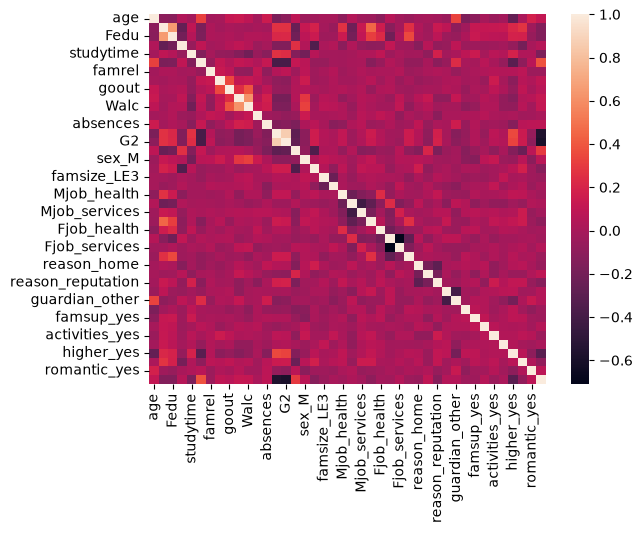

In [4]:
sns.heatmap(df.join(target).corr())
plt.show()




## Работа с моделями

In [5]:
KNN = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=31))
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, class_weight='balanced'))
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
)
CB = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.01,
    depth=10,
    loss_function='Logloss',
    eval_metric='AUC',              
    random_seed=42,
    auto_class_weights='Balanced',  
    verbose=0
)

x_train,x_val,y_train,y_val = train_test_split(df,target,test_size=0.15,stratify=target,random_state=42)
rf.fit(x_train,y_train)
logreg.fit(x_train,y_train)
CB.fit(x_train,y_train)
KNN.fit(x_train,y_train)


cv = StratifiedKFold(5,shuffle=True,random_state=42)
print("KNN:",cross_val_score(KNN,df,target,cv = cv,scoring="roc_auc").mean())
print("LR:",cross_val_score(logreg,df,target,cv = cv,scoring="roc_auc").mean())
print("RF:",cross_val_score(rf,df,target,cv = cv,scoring="roc_auc").mean())
print("CB:",cross_val_score(CB,df,target,cv = cv,scoring="roc_auc").mean())



KNN: 0.9018219349457881
LR: 0.9435863219349457
RF: 0.9685679733110927
CB: 0.9713085904920767


## Порог

[[66 17]
 [ 1 14]]

              precision    recall  f1-score   support

       зачёт       0.99      0.80      0.88        83
     незачёт       0.45      0.93      0.61        15

    accuracy                           0.82        98
   macro avg       0.72      0.86      0.74        98
weighted avg       0.90      0.82      0.84        98



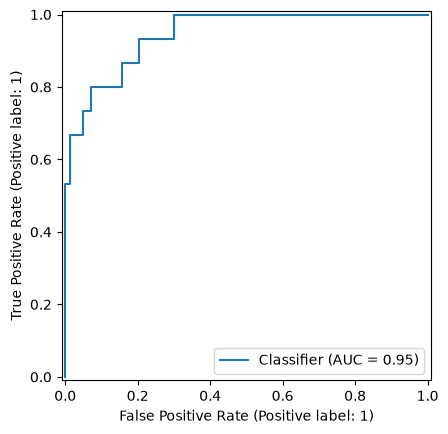

In [6]:
proba = rf.predict_proba(x_val)[:, 1]
threshold = 0.5
Uden_index = []  

#Подбор оптимального порога по индексу Юдена
fpr, tpr, thresholds = roc_curve(y_val, proba)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]

pred = (proba >= optimal_threshold).astype(int)
print(confusion_matrix(y_val, pred))
print()
print(classification_report(y_val, pred, target_names=['зачёт', 'незачёт']))

RocCurveDisplay.from_predictions(y_val, proba)
plt.show()


## Три главных фактора

ТОП-3 фактора:
  1. G2                   падение ROC-AUC при перемешивании: 0.1204
  2. G1                   падение ROC-AUC при перемешивании: 0.0639
  3. famrel               падение ROC-AUC при перемешивании: 0.0047


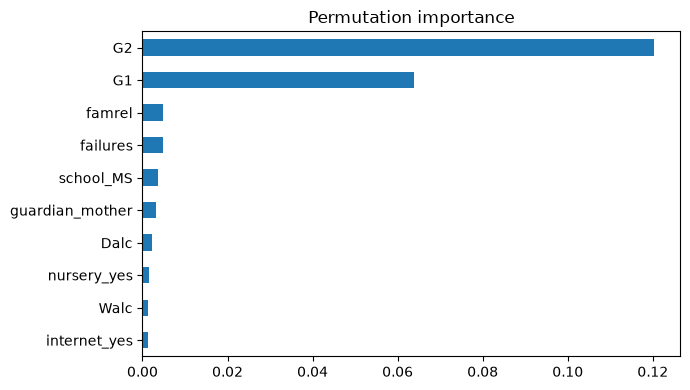

Сильнее всего СНИЖАЮТ риск незачёта:
G2               -3.867
G1               -2.477
age              -0.781
activities_yes   -0.347
Mjob_teacher     -0.270
dtype: float64

Сильнее всего ПОВЫШАЮТ риск незачёта:
Mjob_health        0.287
failures           0.452
Fjob_other         0.522
guardian_mother    0.550
school_MS          0.681
dtype: float64


In [7]:
r = permutation_importance(rf, x_val, y_val, n_repeats=30, random_state=42, scoring='roc_auc')
imp = pd.Series(r.importances_mean, index=df.columns).sort_values(ascending=False)

print('ТОП-3 фактора:')
for i, (name, val) in enumerate(imp.head(3).items(), 1):
    print(f'  {i}. {name:20s} падение ROC-AUC при перемешивании: {val:.4f}')

top = imp.head(10)[::-1]
top.plot(kind='barh', figsize=(7, 4))
plt.title('Permutation importance'); plt.tight_layout(); plt.show()

coefs = pd.Series(logreg.named_steps['logisticregression'].coef_[0], index=df.columns).sort_values()
print('Сильнее всего СНИЖАЮТ риск незачёта:'); print(coefs.head(5).round(3))
print('\nСильнее всего ПОВЫШАЮТ риск незачёта:'); print(coefs.tail(5).round(3))

## Сложный уровень

In [8]:
X2 = df.drop(columns=['G1', 'G2'])
s = cross_val_score(rf, X2, target, cv=cv, scoring='roc_auc')
print(f'без G1 и G2:  ROC-AUC {s.mean():.3f} +- {s.std():.3f}')

X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2, target, test_size=.25, stratify=target, random_state=42)
rf2 = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42).fit(X2_tr, y2_tr)
r2 = permutation_importance(rf2, X2_te, y2_te, n_repeats=30, random_state=42, scoring='roc_auc')
print()
print(pd.Series(r2.importances_mean, index=X2.columns).sort_values(ascending=False).head(5).round(4).to_string())

без G1 и G2:  ROC-AUC 0.829 +- 0.029

school_MS          0.0724
failures           0.0522
higher_yes         0.0368
guardian_mother    0.0095
Mjob_health        0.0040


## Бонус

In [14]:
mat_df = pd.read_csv("student-mat.csv",sep=";")

mat_target = (mat_df['G3'] < 10).astype(int)
mat_df = mat_df.drop(columns="G3")
mat_df = pd.get_dummies(mat_df,drop_first=True)

# 1. Модель со всеми признаками (включая G1 и G2)
rf_full = RandomForestClassifier(
    n_estimators=400, class_weight='balanced', random_state=42
)

rf_full.fit(df, target)
auc_full_transfer = roc_auc_score(mat_target, rf_full.predict_proba(mat_df)[:, 1])
print(f'Полная модель: ROC-AUC на математике = {auc_full_transfer:.3f}')

# 2. Модель без G1 и G2
cols_without_g1g2 = [c for c in df.columns if c not in ['G1', 'G2']]
por_complex = df[cols_without_g1g2]
mat_complex = mat_df[cols_without_g1g2]

rf_complex = RandomForestClassifier(
    n_estimators=400, class_weight='balanced', random_state=42
)
rf_complex.fit(por_complex, target)
auc_complex_transfer = roc_auc_score(mat_target, rf_complex.predict_proba(mat_complex)[:, 1])
print(f'Модель без G1/G2: ROC-AUC на математике = {auc_complex_transfer:.3f}')

# Для наглядности: качество обеих моделей на самом португальском (отложенная выборка)
X_tr_full, X_te_full, y_tr_full, y_te_full = train_test_split(
    df, target, test_size=0.25, stratify=target, random_state=42
)
rf_full_cv = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42)
rf_full_cv.fit(X_tr_full, y_tr_full)
auc_full_por = roc_auc_score(y_te_full, rf_full_cv.predict_proba(X_te_full)[:, 1])

X_tr_complex, X_te_complex, y_tr_complex, y_te_complex = train_test_split(
    por_complex, target, test_size=0.25, stratify=target, random_state=42
)
rf_complex_cv = RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42)
rf_complex_cv.fit(X_tr_complex, y_tr_complex)
auc_complex_por = roc_auc_score(y_te_complex, rf_complex_cv.predict_proba(X_te_complex)[:, 1])

print(f'\nСравнение AUC:')
print(f'  Полная модель:      Португальский (отлож.) = {auc_full_por:.3f}, Математика = {auc_full_transfer:.3f}')
print(f'  Без G1 и G2:        Португальский (отлож.) = {auc_complex_por:.3f}, Математика = {auc_complex_transfer:.3f}')

Полная модель: ROC-AUC на математике = 0.955
Модель без G1/G2: ROC-AUC на математике = 0.645

Сравнение AUC:
  Полная модель:      Португальский (отлож.) = 0.946, Математика = 0.955
  Без G1 и G2:        Португальский (отлож.) = 0.791, Математика = 0.645


Перенос модели, обученной на португальском языке, на математику показывает, что без оценок за текущий период (G1 и G2) качество предсказания заметно снижается (ROC-AUC). Это указывает на то, что личные признаки студента оказывают разное влияние на успеваемость по разным предметам, и универсальной модели "студента вообще" на их основе построить нельзя. Однако полная модель, включающая промежуточные оценки по предмету, почти полностью сохраняет точность, так как эти оценки отражают и общий академический потенциал учащегося. Таким образом, выявленные ранее "три главных фактора" в значительной степени привязаны к конкретному предмету, но не полностью лишены общей составляющей.